# Atividade: CNNs para Classificação

Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

## 1. Instalação de Dependências

In [16]:
# Execute esta célula e depois reinicie o kernel
!pip install icrawler torch torchvision pillow matplotlib seaborn scikit-learn tqdm

## 2. Imports

In [17]:
import os
import shutil
import random
from icrawler.builtin import BingImageCrawler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models, utils
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm.notebook import tqdm

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 3. Download de Imagens

Utilizei a  **BingImageCrawler**  para baixar imagens dos jogadores.

In [18]:
def download_images_bing(keyword, folder, n_total=100):
    """
    Baixa imagens usando BingImageCrawler do icrawler
    """
    os.makedirs(folder, exist_ok=True)


    # Verificar quantas imagens já existem
    existing_files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    downloaded = len(existing_files)

    if downloaded >= n_total:
        return

    remaining = n_total - downloaded


    try:
        # Usar BingImageCrawler
        crawler = BingImageCrawler(storage={'root_dir': folder})
        crawler.crawl(
            keyword=keyword,
            max_num=remaining,
            file_idx_offset=downloaded
        )

        # Contar novamente
        new_files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
        total = len(new_files)


    except Exception as e:
        current = len([f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))])

In [19]:
search_terms = {
    "lebron_james": "Lebron James NBA",
    "stephen_curry": "Stephen Curry NBA"
}


for label, term in search_terms.items():
    download_images_bing(term, f"data/nba_players/{label}", n_total=200)

for label in search_terms.keys():
    folder = f"data/nba_players/{label}"
    if os.path.exists(folder):
        count = len([f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))])


ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/lebron-james-lakers-new_bGxra2uUmZqaraWkpJRoZWVlrWdlZWU.jpg
ERROR:downloader:Response status code 403, file https://sports.inquirer.net/files/2022/06/2022-06-11T040218Z_1_LYNXMPEI5A01A_RTROPTP_4_BASKETBALL-NBA-BOS-GSW-scaled.jpg
ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/stephen-curry-nba-final-mvp-2022_bWlpaGWUmZqaraWkpJRmamhrrWdlaW0.jpg
ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/nba-finals-mvp-stephen-curry_bWloZm2UmZqaraWkpJRmbmdlrWZlbWU.jpg
ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/stephen-curry-nba-75-mvp-and-champion_bWlpaGqUmZqaraWkpJRmZW1lrWZuZ2U.jpg
ERROR:downloader:Response status code 403, file https://wallpapercrafter.com/desktop3/994956-Basketball-Stephen-Curry-Golden-State-Warriors-NBA.jpg
ERROR:downloader:Response statu

## 4. Divisão Train/Validation

In [20]:
def split_train_val(root_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = root_dir + "_split/train"
    val_dir = root_dir + "_split/val"

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

# Executar a divisão
split_train_val("data/nba_players", train_ratio=0.8)

stephen_curry: 127 train, 32 val
lebron_james: 71 train, 18 val


## 5. Dataset Custom e DataLoaders

Classes: ['lebron_james', 'stephen_curry']
Tamanho do dataset de treino: 226
Tamanho do dataset de validação: 86


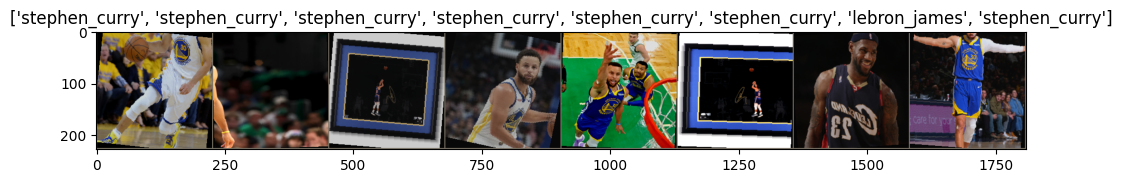

In [21]:
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.class_names = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}
        self.data = []

        for class_name in self.class_names:
            class_dir = os.path.join(self.root_dir, class_name)
            for filename in os.listdir(class_dir):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    path = os.path.join(class_dir, filename)
                    item = (path, self.class_to_idx[class_name])
                    self.data.append(item)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]
        try:
            image = Image.open(path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading image {path}: {e}")
            if self.transform:
                return self.transform(Image.new('RGB', (224, 224))), label
            return Image.new('RGB', (224, 224)), label

# Definindo as transformações com data augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'data/nba_players_split'

# Criando instâncias de Dataset
train_dataset = CustomImageDataset(os.path.join(data_dir, 'train'), data_transforms['train'])
val_dataset = CustomImageDataset(os.path.join(data_dir, 'val'), data_transforms['val'])

# Criando instâncias de DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

# Obtendo informações
class_names = train_dataset.class_names
train_size = len(train_dataset)
val_size = len(val_dataset)

print(f"Classes: {class_names}")
print(f"Tamanho do dataset de treino: {train_size}")
print(f"Tamanho do dataset de validação: {val_size}")

# Visualizando algumas imagens
def imshow(inp, title=None):
    """Função para exibir um tensor de imagem."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Obtém um batch de dados de treino
inputs, classes = next(iter(train_dataloader))

# Cria uma grade a partir do batch
out = utils.make_grid(inputs[:8])
plt.figure(figsize=(12, 6))
imshow(out, title=[class_names[x] for x in classes[:8]])
plt.show()

## 6. Definição do Modelo (Transfer Learning)

In [22]:
# Usando Transfer Learning com ResNet18
model = models.resnet18(pretrained=True)

# Congelando as camadas convolucionais
for param in model.parameters():
    param.requires_grad = False

# Substituindo a última camada fully connected
num_classes = len(class_names)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, num_classes)
)

# Movendo o modelo para a GPU se disponível
model = model.to(device)

print(f"Modelo: ResNet18")
print(f"Número de classes: {num_classes}")
print(f"Classes: {class_names}")
print(f"\nÚltima camada do modelo:")
print(model.fc)

Modelo: ResNet18
Número de classes: 2
Classes: ['lebron_james', 'stephen_curry']

Última camada do modelo:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=2, bias=True)
)


## 7. Treinamento


Epoch 1/15
------------------------------------------------------------


Train:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 0.7607 Acc: 0.5929


Val:   0%|          | 0/6 [00:00<?, ?it/s]

Val Loss: 0.5153 Acc: 0.7209
0.7209

Epoch 2/15
------------------------------------------------------------


...

Val Loss: 0.1733 Acc: 0.9535

Epoch 15/15
------------------------------------------------------------


Train:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 0.4431 Acc: 0.7920


Val:   0%|          | 0/6 [00:00<?, ?it/s]

Val Loss: 0.1729 Acc: 0.9419


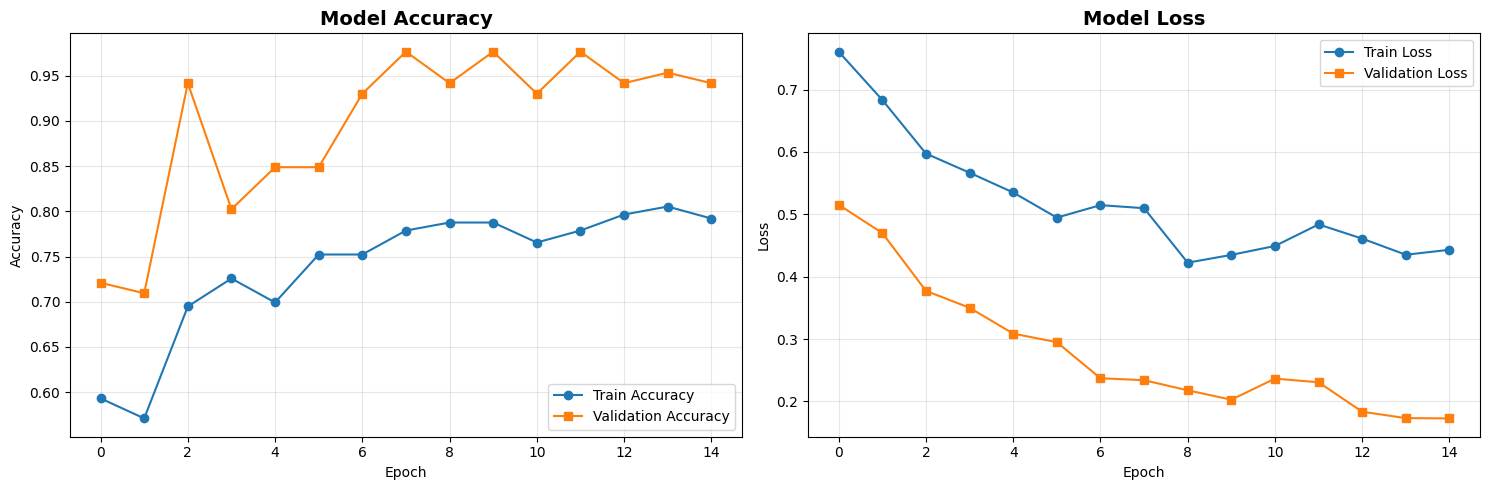

In [23]:
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=25):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 60)

        for phase, loader in [('train', train_loader), ('val', val_loader)]:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            size = len(loader.dataset)

            loop = tqdm(loader, desc=f'{phase.capitalize()}')

            for inputs, labels in loop:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                loop.set_postfix(loss=loss.item())

            epoch_loss = running_loss / size
            epoch_acc = running_corrects.double() / size

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), 'best_model.pth')
                print(f'{best_acc:.4f}')


    return history

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history['train_acc'], label='Train Accuracy', marker='o')
    ax1.plot(history['val_acc'], label='Validation Accuracy', marker='s')
    ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['train_loss'], label='Train Loss', marker='o')
    ax2.plot(history['val_loss'], label='Validation Loss', marker='s')
    ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Definindo a função de custo e otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Treinando o modelo
num_epochs = 15
history = train_model(model, criterion, optimizer, train_dataloader, val_dataloader, num_epochs=num_epochs)

# Plotando as curvas de treinamento
plot_history(history)

## 8. Avaliação e Inferência

Avaliando:   0%|          | 0/6 [00:00<?, ?it/s]

Acurácia


Relatório de Classificação:
               precision    recall  f1-score   support

 lebron_james       0.97      0.97      0.97        30
stephen_curry       0.98      0.98      0.98        56

     accuracy                           0.98        86
    macro avg       0.97      0.97      0.97        86
 weighted avg       0.98      0.98      0.98        86



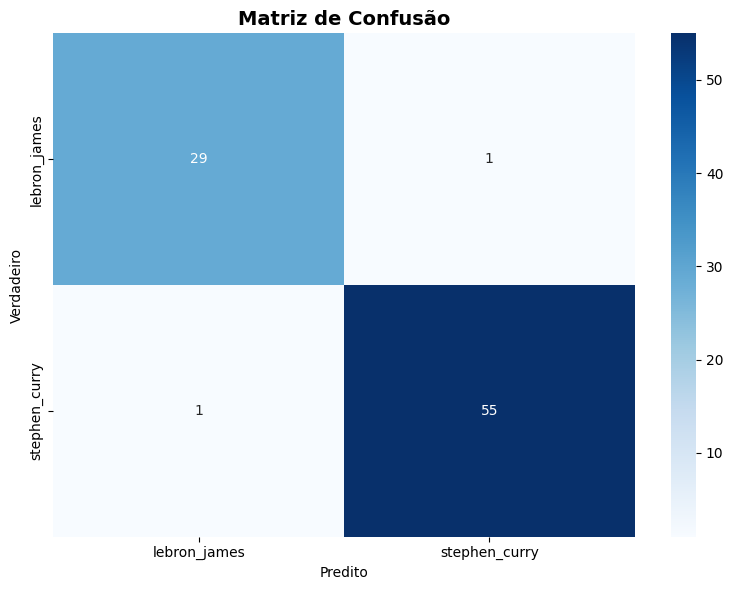


predições no conjunto de validação:


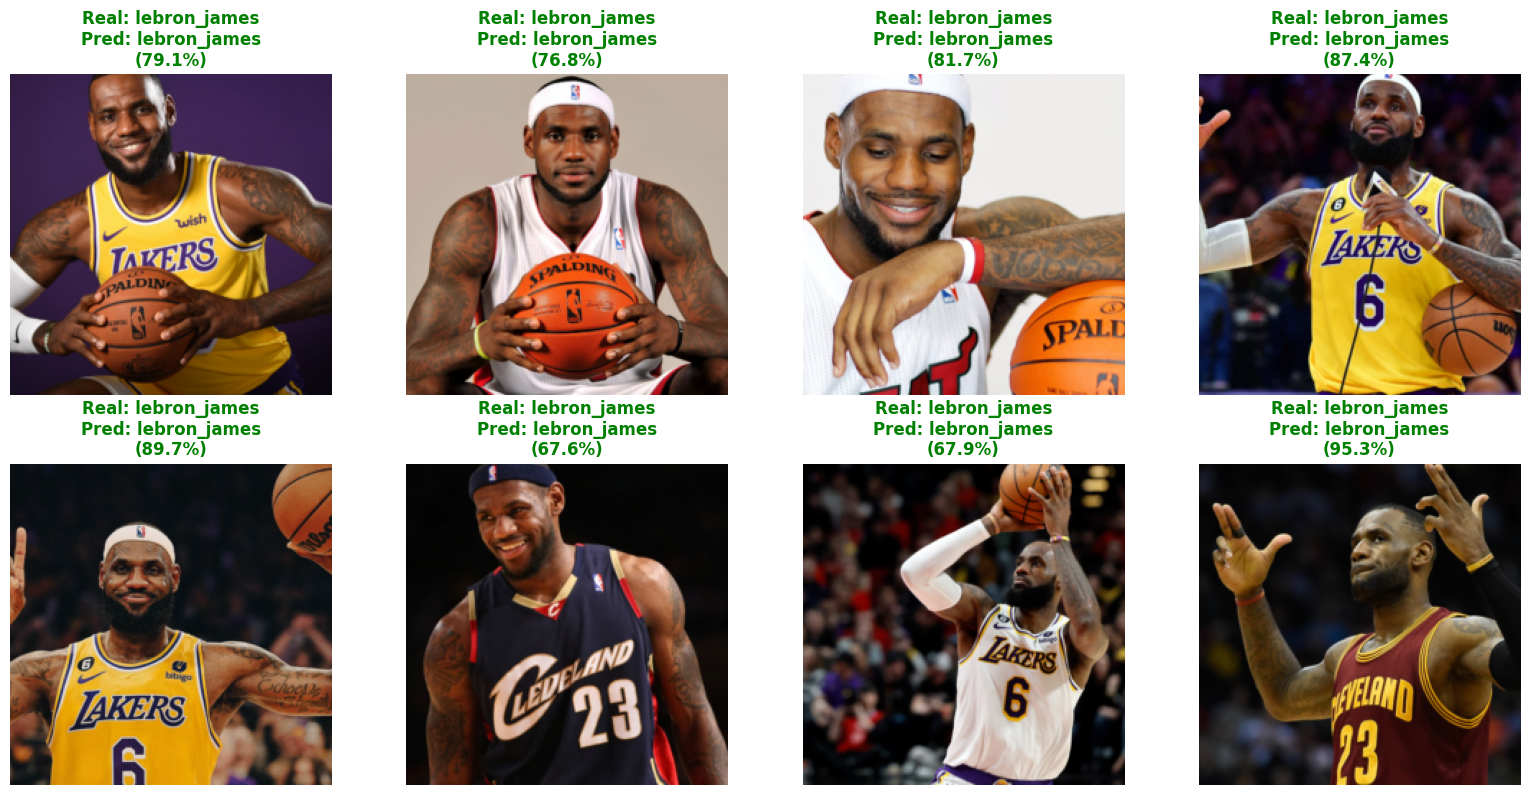

In [27]:
# Carregar o melhor modelo
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

def evaluate_model(model, val_loader):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc='Avaliando'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

# Obter predições
preds, labels = evaluate_model(model, val_dataloader)

# Calcular acurácia
accuracy = (preds == labels).sum() / len(labels)
print(f"Acurácia")
print("\n" + "="*60)

# Relatório de classificação
print("\nRelatório de Classificação:")
print("="*60)
print(classification_report(labels, preds, target_names=class_names))

# Matriz de confusão
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão', fontsize=14, fontweight='bold')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.tight_layout()
plt.show()

# Função para testar em uma nova imagem
def predict_image(image_path, model, transform, class_names):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = class_names[predicted.item()]
    confidence_score = confidence.item()

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Predição: {predicted_class}\nConfiança: {confidence_score:.2%}',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nProbabilidades")
    print("="*40)
    for i, class_name in enumerate(class_names):
        prob = probabilities[0][i].item()
        bar = '█' * int(prob * 50)
        print(f"{class_name:20s}: {prob:6.2%} {bar}")

    return predicted_class, confidence_score

# Visualizar predições
def visualize_predictions(model, val_loader, class_names, num_images=8):
    model.eval()
    images_shown = 0
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)

            for i in range(inputs.size(0)):
                if images_shown >= num_images:
                    break

                img = inputs[i].cpu().numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                ax = axes[images_shown]
                ax.imshow(img)
                ax.axis('off')

                pred_class = class_names[preds[i]]
                true_class = class_names[labels[i]]
                confidence = probabilities[i][preds[i]].item()

                color = 'green' if preds[i] == labels[i] else 'red'
                title = f'Real: {true_class}\nPred: {pred_class}\n({confidence:.1%})'
                ax.set_title(title, color=color, fontweight='bold')

                images_shown += 1

            if images_shown >= num_images:
                break

    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("predições no conjunto de validação:")
print("="*60)
visualize_predictions(model, val_dataloader, class_names, num_images=8)